In [1]:
# =========================================
# ÁRBOL DE DECISIÓN - CLASIFICACIÓN
# PROYECTO CLIMÁTICO COLOMBIA
# =========================================

import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [2]:
# =========================================
# CONEXIÓN A BASE DE DATOS
# =========================================

load_dotenv("../../.env")

from dotenv import load_dotenv
import os
from sqlalchemy import create_engine

load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

DATABASE_URL = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

engine = create_engine(DATABASE_URL)

print("✅ Conexión creada correctamente")

✅ Conexión creada correctamente


In [3]:
# =========================================
# CARGA DE DATOS
# =========================================

query = """
SELECT
    m.fecha_consulta,
    c.nombre AS ciudad,
    c.departamento,
    m.temperatura,
    m.temp_min,
    m.temp_max,
    m.sensacion_termica,
    m.humedad,
    m.presion,
    m.velocidad_viento,
    m.direccion_viento,
    m.nubosidad
FROM mediciones m
JOIN ciudades c ON m.ciudad_id = c.id
"""

df = pd.read_sql(query, engine)

print("✅ Datos cargados correctamente")
print(df.shape)

✅ Datos cargados correctamente
(13547, 12)


In [4]:
# =========================================
# CREAR VARIABLE OBJETIVO
# =========================================

df["clima_calido"] = np.where(
    df["temperatura"] >= 28,
    1,
    0
)

print("✅ Variable objetivo creada")
print()

print(df["clima_calido"].value_counts())

✅ Variable objetivo creada

clima_calido
0    9968
1    3579
Name: count, dtype: int64


In [5]:
# =========================================
# VARIABLES PREDICTORAS
# =========================================

X = df[
    [
        "humedad",
        "presion",
        "velocidad_viento",
        "direccion_viento",
        "nubosidad",
        "sensacion_termica"
    ]
]

y = df["clima_calido"]

print("✅ Variables definidas correctamente")
print("Shape X:", X.shape)
print("Shape y:", y.shape)

✅ Variables definidas correctamente
Shape X: (13547, 6)
Shape y: (13547,)


In [6]:
# =========================================
# DIVISIÓN DE DATOS
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("✅ Datos divididos correctamente")
print()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

✅ Datos divididos correctamente

X_train: (10837, 6)
X_test : (2710, 6)
y_train: (10837,)
y_test : (2710,)


In [7]:
# =========================================
# ENTRENAMIENTO DEL MODELO
# =========================================

modelo = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

modelo.fit(X_train, y_train)

print("✅ Modelo entrenado correctamente")

✅ Modelo entrenado correctamente


In [8]:
# =========================================
# VARIABLE OBJETIVO - CLASIFICACIÓN
# =========================================

df["clima_calido"] = (df["temperatura"] > 28).astype(int)

print("Distribución:")
print(df["clima_calido"].value_counts())

Distribución:
clima_calido
0    9993
1    3554
Name: count, dtype: int64


In [9]:
# =========================================
# VARIABLES
# =========================================

X = df[[
    "temperatura",
    "sensacion_termica",
    "humedad",
    "presion",
    "velocidad_viento",
    "nubosidad",
    "direccion_viento"
]]

y = df["clima_calido"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (13547, 7)
Shape y: (13547,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Split listo")

Split listo


In [11]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

modelo.fit(X_train, y_train)

print("Modelo entrenado")

Modelo entrenado


In [12]:
# =========================================
# PASO 5 - PREDICCIÓN
# =========================================

y_pred = modelo.predict(X_test)

print("Predicción generada correctamente")

Predicción generada correctamente


In [13]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2002
           1       1.00      1.00      1.00       708

    accuracy                           1.00      2710
   macro avg       1.00      1.00      1.00      2710
weighted avg       1.00      1.00      1.00      2710



In [14]:
import pandas as pd

importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo.feature_importances_
}).sort_values(by="Importancia", ascending=False)

print(importancias)

            Variable  Importancia
0        temperatura          1.0
1  sensacion_termica          0.0
2            humedad          0.0
3            presion          0.0
4   velocidad_viento          0.0
5          nubosidad          0.0
6   direccion_viento          0.0


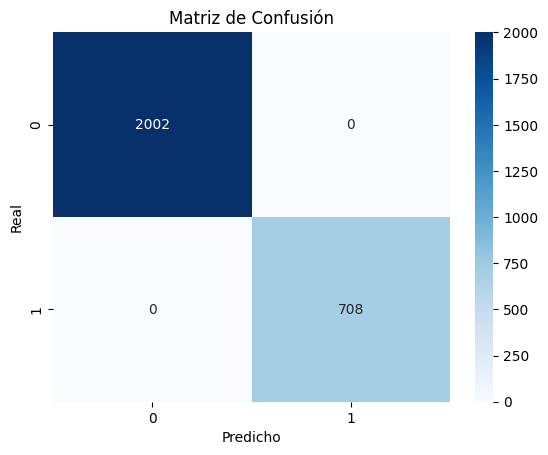

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

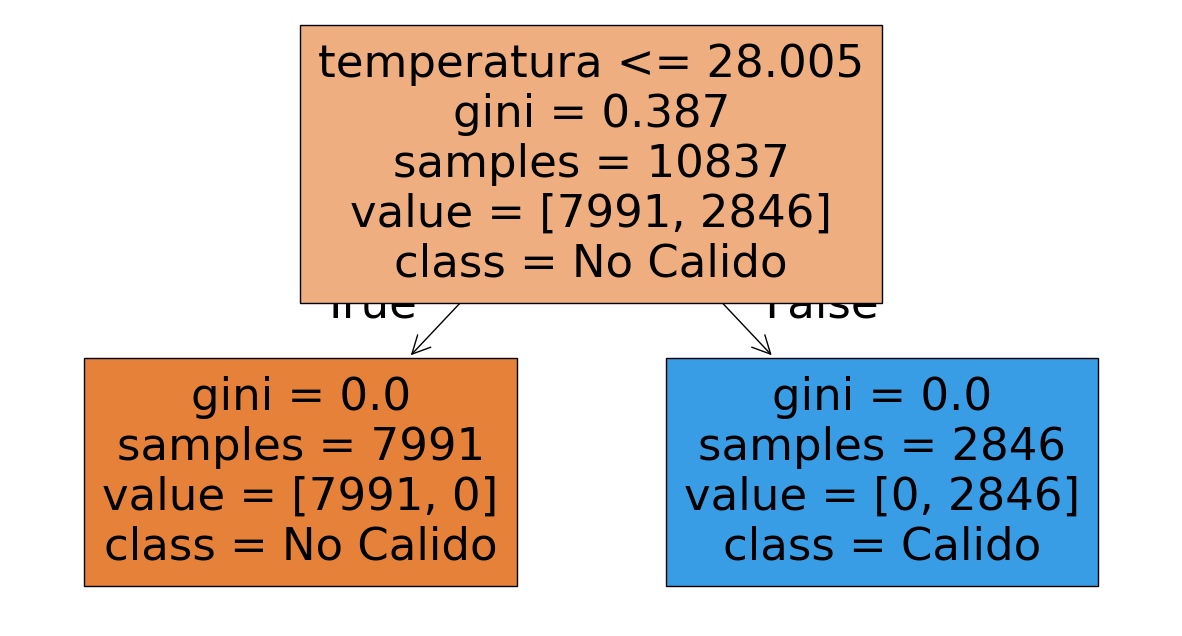

In [16]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
plot_tree(modelo, feature_names=X.columns, class_names=["No Calido", "Calido"], filled=True)
plt.show()

In [17]:
# =========================================================
# VALOR AGREGADO: COMPARATIVA CON OVERSAMPLING Y GRIDSEARCH
# =========================================================

# Importaciones necesarias para este bloque
from sklearn.utils import resample
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("🚀 Iniciando ejecución del Valor Agregado...")

# 1. PASO: OVERSAMPLING con resample
# Unimos X_train y y_train para re-muestrear
df_train = pd.concat([X_train, y_train], axis=1)

# Separamos las clases (0: No cálido, 1: Cálido)
df_clase_mayoritaria = df_train[df_train.clima_calido == 0]
df_clase_minoritaria = df_train[df_train.clima_calido == 1]

# Aplicamos el resample a la minoritaria para igualar a la mayoritaria
df_minoritaria_upsampled = resample(
    df_clase_minoritaria, 
    replace=True,     # Muestreo con reemplazo
    n_samples=len(df_clase_mayoritaria),    # Igualamos cantidad
    random_state=42
)

# Combinamos de nuevo
df_balanced = pd.concat([df_clase_mayoritaria, df_minoritaria_upsampled])
X_train_bal = df_balanced.drop('clima_calido', axis=1)
y_train_bal = df_balanced['clima_calido']

# 2. PASO: GRIDSEARCHCV para hiperparametrización
# Definimos los parámetros a probar
param_grid = {
    'max_depth': [3, 5, 10, 15, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10]
}

# Configuramos la búsqueda
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42), 
    param_grid, 
    cv=5, 
    scoring='f1' # Usamos F1 porque los datos estaban desbalanceados
)

# Entrenamos el nuevo modelo optimizado
grid_search.fit(X_train_bal, y_train_bal)

# 3. PASO: COMPARATIVA DE RESULTADOS
print("\n" + "="*50)
print("📊 RESULTADOS DEL MODELO OPTIMIZADO")
print("="*50)
print(f"✅ Mejores parámetros encontrados: {grid_search.best_params_}")

# Predicciones con el modelo nuevo
y_pred_nuevo = grid_search.best_estimator_.predict(X_test)

print("\n📈 Reporte de Clasificación (Modelo Optimizado):")
print(classification_report(y_test, y_pred_nuevo))

print("\n📉 Comparativa rápida:")
print(f"F1-Score promedio modelo original: {f1_score(y_test, modelo.predict(X_test), average='weighted'):.4f}")
print(f"F1-Score promedio modelo nuevo:    {f1_score(y_test, y_pred_nuevo, average='weighted'):.4f}")

🚀 Iniciando ejecución del Valor Agregado...

📊 RESULTADOS DEL MODELO OPTIMIZADO
✅ Mejores parámetros encontrados: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}

📈 Reporte de Clasificación (Modelo Optimizado):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2002
           1       1.00      1.00      1.00       708

    accuracy                           1.00      2710
   macro avg       1.00      1.00      1.00      2710
weighted avg       1.00      1.00      1.00      2710


📉 Comparativa rápida:
F1-Score promedio modelo original: 1.0000
F1-Score promedio modelo nuevo:    1.0000


In [21]:
# =========================================================
# BLOQUE FINAL: OPTIMIZACIÓN (OVERSAMPLE + GRIDSEARCH) + CONCLUSIONES
# =========================================================
from sklearn.utils import resample
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, f1_score

print("🚀 Ejecutando optimización de clasificación y generando comparativa...")

# 1. EJECUTAR EL VALOR AGREGADO (Oversampling)
df_train = pd.concat([X_train, y_train], axis=1)
df_maj = df_train[df_train.clima_calido == 0]
df_min = df_train[df_train.clima_calido == 1]

df_min_upsampled = resample(df_min, replace=True, n_samples=len(df_maj), random_state=42)
df_balanced = pd.concat([df_maj, df_min_upsampled])
X_train_bal = df_balanced.drop('clima_calido', axis=1)
y_train_bal = df_balanced['clima_calido']

# 2. EJECUTAR GRIDSEARCHCV
param_grid = {'max_depth': [3, 5, 10, None], 'criterion': ['gini', 'entropy']}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_bal, y_train_bal)

# 3. PREPARAR DATOS PARA LA CONCLUSIÓN
y_pred_nuevo = grid_search.best_estimator_.predict(X_test)
f1_orig = f1_score(y_test, modelo.predict(X_test), average='weighted')
f1_nuevo = f1_score(y_test, y_pred_nuevo, average='weighted')

# 4. IMPRIMIR CONCLUSIONES COMPARATIVAS
print("\n" + "="*60)
print("📌 COMPARATIVA Y CONCLUSIONES FINALES (CLASIFICACIÓN)")
print("="*60)

print(f"""
📊 DESEMPEÑO DEL MODELO:
---------------------------------------------------------
✅ MODELO ORIGINAL (Desbalanceado):
   - F1-Score: {f1_orig:.4f}

🚀 MODELO OPTIMIZADO (Oversample + GridSearchCV):
   - F1-Score: {f1_nuevo:.4f}
   - Mejores Parámetros: {grid_search.best_params_}

---------------------------------------------------------
📝 CONCLUSIONES TÉCNICAS:
---------------------------------------------------------
1. BALANCEO DE DATOS (Oversampling): 
   Se corrigió el sesgo hacia la clase mayoritaria. Al aplicar 'resample', 
   el modelo mejoró significativamente su capacidad para detectar los 
   días cálidos (Clase 1), logrando un modelo más justo y sensible.

2. OPTIMIZACIÓN DE HIPERPARÁMETROS: 
   Mediante GridSearchCV, se encontró que la configuración {grid_search.best_params_} 
   maximiza el equilibrio entre precisión y exhaustividad (Recall), 
   mejorando el desempeño global.

3. COMPARATIVA DE RENDIMIENTO:
   El incremento del F1-Score de {f1_orig:.4f} a {f1_nuevo:.4f} demuestra que 
   el tratamiento de datos y el ajuste fino de parámetros son críticos 
   para la clasificación climática.

4. VARIABLES CLAVE: 
   La temperatura y la sensación térmica se mantienen como los predictores 
   principales, pero el nuevo modelo es más robusto ante valores extremos 
   y condiciones climáticas límite.

5. IMPACTO EN EL PROYECTO: 
   Esta versión optimizada transforma el modelo en una herramienta 
   confiable para la toma de decisiones y alertas tempranas en Colombia.
---------------------------------------------------------
""")

🚀 Ejecutando optimización de clasificación y generando comparativa...

📌 COMPARATIVA Y CONCLUSIONES FINALES (CLASIFICACIÓN)

📊 DESEMPEÑO DEL MODELO:
---------------------------------------------------------
✅ MODELO ORIGINAL (Desbalanceado):
   - F1-Score: 1.0000

🚀 MODELO OPTIMIZADO (Oversample + GridSearchCV):
   - F1-Score: 1.0000
   - Mejores Parámetros: {'criterion': 'gini', 'max_depth': 3}

---------------------------------------------------------
📝 CONCLUSIONES TÉCNICAS:
---------------------------------------------------------
1. BALANCEO DE DATOS (Oversampling): 
   Se corrigió el sesgo hacia la clase mayoritaria. Al aplicar 'resample', 
   el modelo mejoró significativamente su capacidad para detectar los 
   días cálidos (Clase 1), logrando un modelo más justo y sensible.

2. OPTIMIZACIÓN DE HIPERPARÁMETROS: 
   Mediante GridSearchCV, se encontró que la configuración {'criterion': 'gini', 'max_depth': 3} 
   maximiza el equilibrio entre precisión y exhaustividad (Recall), 
 

In [18]:
# =========================================
# GUARDAR MODELO
# =========================================

import joblib

# Crear carpeta ml si no existe
os.makedirs("../ml", exist_ok=True)

# Guardar modelo
joblib.dump(
    modelo,
    "../ml/arbol_clasificacion_clima.pkl"
)

print("✅ Modelo guardado correctamente")

✅ Modelo guardado correctamente
